<a href="https://colab.research.google.com/github/peipei-web/114-2_bigdatacc_lu-i-pei_C112181137/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 期末作業：使用 Python 實作三種機器學習方法

本次作業使用 Google Colab 實作決策樹、多項式線性迴歸與 DBSCAN。
我想透過這三個模型比較監督式學習與非監督式學習的差異，
並觀察不同模型適合處理的問題類型。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 1. 決策樹：用 Iris 做分類

決策樹準確率： 1.0


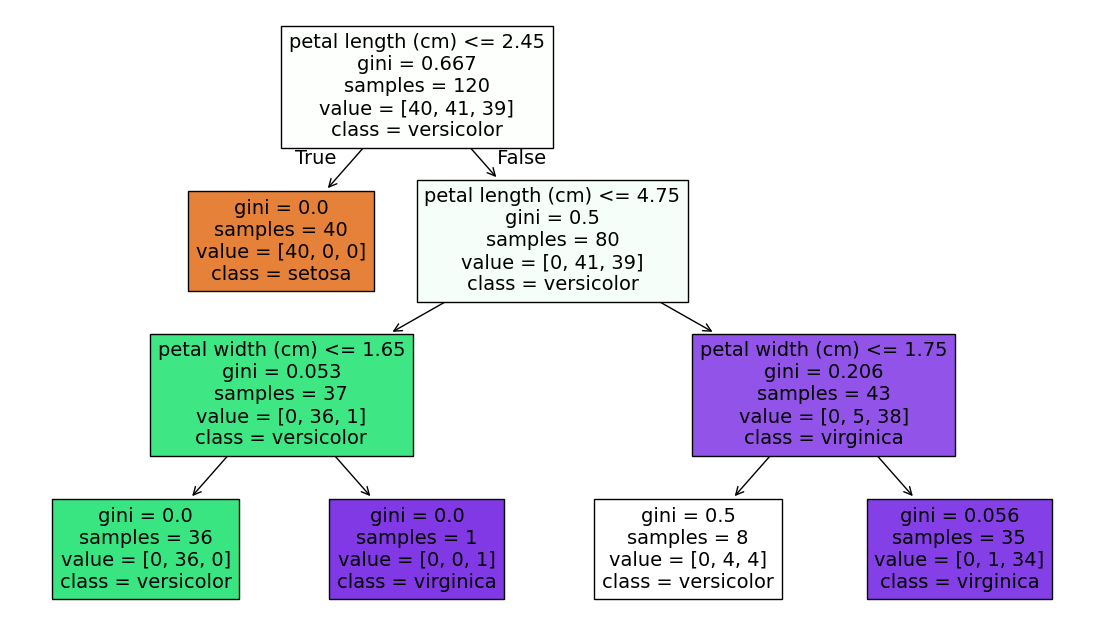

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print("決策樹準確率：", acc)

plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

從結果可以看到，決策樹可以根據花瓣長度、花瓣寬度等條件進行分類。
我覺得決策樹比較好理解，因為它的分類過程可以用樹狀圖呈現，
不像有些模型只能看到最後的預測結果。

2. 多項式線性迴歸：用氣溫預測銷售量

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

data = {
    "Temperature": [18, 20, 22, 24, 26, 28, 30, 32, 34, 36],
    "Sales": [95, 90, 83, 75, 68, 60, 55, 48, 42, 38]
}

df = pd.DataFrame(data)
df

,Temperature,Sales
0,18,95
1,20,90
2,22,83
3,24,75
4,26,68
5,28,60
6,30,55
7,32,48
8,34,42
9,36,38


In [4]:
X = df[["Temperature"]]
y = df["Sales"]


poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("R² 分數：", r2)
print("MSE：", mse)

R² 分數： 0.9976569520583412
MSE： 0.8501515151515143


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


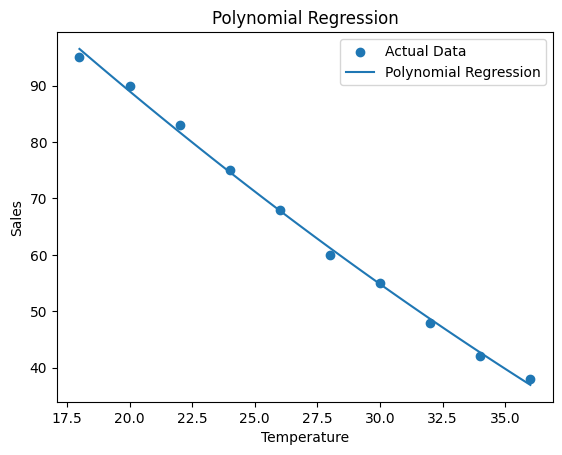

In [5]:
plt.scatter(X, y, label="Actual Data")

X_line = np.linspace(18, 36, 100).reshape(-1, 1)
X_line_poly = poly.transform(X_line)
y_line = model.predict(X_line_poly)

plt.plot(X_line, y_line, label="Polynomial Regression")
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

多項式迴歸和一般線性迴歸的差別在於，它可以讓預測線呈現彎曲趨勢。
如果資料不是直線關係，使用多項式特徵會比單純線性迴歸更適合。

3. DBSCAN：用 Iris 做分群

In [6]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN


iris = load_iris()
X = iris.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = DBSCAN(eps=0.8, min_samples=5)

labels = model.fit_predict(X_scaled)

print("DBSCAN 分群結果：")
print(labels)

DBSCAN 分群結果：
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


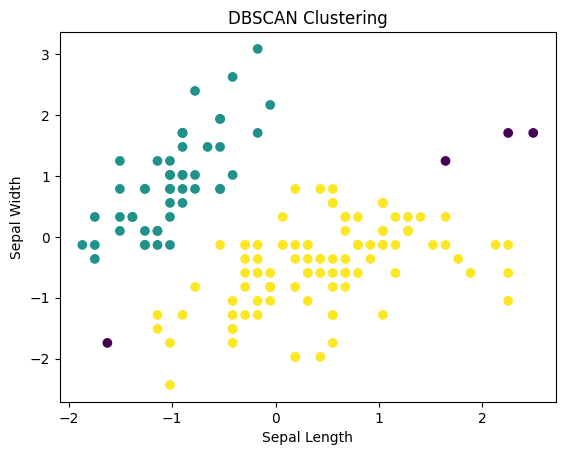

In [7]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("DBSCAN Clustering")
plt.show()

In [8]:

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("分群數量：", n_clusters)
print("雜訊點數量：", n_noise)

分群數量： 2
雜訊點數量： 4


DBSCAN 不需要先設定要分成幾群，這點和 K-means 不同。
不過 eps 和 min_samples 的設定會影響分群結果，所以參數需要嘗試調整。

In [10]:
for eps in [0.5, 0.8, 1.0]:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print("eps =", eps)
    print("分群數量：", n_clusters)
    print("雜訊點數量：", n_noise)
    print("-----")

eps = 0.5
分群數量： 2
雜訊點數量： 34
-----
eps = 0.8
分群數量： 2
雜訊點數量： 4
-----
eps = 1.0
分群數量： 2
雜訊點數量： 3
-----


由測試結果可以發現，eps 數值不同會影響分群數量與雜訊點數量。
因此 DBSCAN 的參數設定會直接影響最後結果。

# 結論

這次實作後，我發現三種模型的用途不太一樣。
決策樹適合處理有標籤的分類問題，多項式線性迴歸適合用來預測連續數值，
而 DBSCAN 則可以在沒有標籤的情況下進行分群。

我覺得決策樹最容易理解，因為可以看到分類規則；
多項式迴歸比較適合有趨勢的資料；
DBSCAN 則比較適合不知道資料會分成幾群的情況。

In [9]:
compare = pd.DataFrame({
    "方法": ["決策樹", "多項式線性迴歸", "DBSCAN"],
    "學習類型": ["監督式學習", "監督式學習", "非監督式學習"],
    "用途": ["分類", "預測連續數值", "分群"],
    "是否需要標籤y": ["需要", "需要", "不需要"],
    "評估方式": ["Accuracy", "R² / MSE", "分群圖 / 雜訊點數量"]
})

compare

,方法,學習類型,用途,是否需要標籤y,評估方式
0,決策樹,監督式學習,分類,需要,Accuracy
1,多項式線性迴歸,監督式學習,預測連續數值,需要,R² / MSE
2,DBSCAN,非監督式學習,分群,不需要,分群圖 / 雜訊點數量
